# Example 7: Source Spectrum & Water age

This example demonstrates how GeoDataFrames (gdfs) and V3_dataframe created by PT3S can be used with matplotlib to create an interactive depiction of a source spectrum.

# Example 7.1: Source Spectrum

## PT3S Release

In [94]:
#pip install PT3S -U --no-deps

## Necessary packages for this Example

When running this example for the first time on your machine, please execute the cell below. Afterward, you may need to restart the kernel (using the ‘fast-forward’ button).

In [1]:
#!pip install -q shapely ipywidgets

## Imports

In [2]:
import os
import logging
import pandas as pd
from pandas import Timestamp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Point
from matplotlib.patches import Circle
import ipywidgets as widgets
from matplotlib.collections import LineCollection
from matplotlib.cm import get_cmap
import networkx
import re
from shapely.geometry import LineString
import networkx
from scipy.sparse import csc_matrix
#...

try:
    from PT3S import dxAndMxHelperFcts
except:
    import dxAndMxHelperFcts

try:
    from PT3S import Rm
except:
    import Rm

try:
    from PT3S import ncd
except:
    import ncd
#...

In [3]:
import importlib
from importlib import resources

In [4]:
#importlib.reload(ncd)

## Logging

In [5]:
logger = logging.getLogger()

if not logger.handlers:
    logFileName = r"Example7.log"
    loglevel = logging.DEBUG

    logging.basicConfig(
        filename=logFileName,
        filemode='w',
        level=loglevel,
        format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s"
    )

    fileHandler = logging.FileHandler(logFileName)
    logger.addHandler(fileHandler)

    consoleHandler = logging.StreamHandler()
    consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
    consoleHandler.setLevel(logging.INFO)
    logger.addHandler(consoleHandler)


## Read Model and Results

In [6]:
dbFilename="Example5"
dbFile = resources.files("PT3S").joinpath("Examples", f"{dbFilename}.db3")

In [7]:
m=dxAndMxHelperFcts.readDxAndMx(dbFile=dbFile
                                ,preventPklDump=True
                                ,maxRecords=-1
                                ,SirCalcExePath=r"C:\3S\SIR 3S\SirCalc-90-14-02-12_Potsdam.fix1_x64\SirCalc.exe"
                                )

INFO    ; Dx.__init__: dbFile (abspath): c:\users\aUserName\3s\pt3s\PT3S\Examples\Example5.db3 exists readable ...
INFO    ; PT3S.dxAndMxHelperFcts.readDxAndMx: 
+..\PT3S\Examples\Example5.db3 is newer than
+..\PT3S\Examples\WDExample5\B1\V0\BZ1\M-1-0-1.1.MX1:
+SIR 3S' dbFile is newer than SIR 3S' mx1File
+in this case the results are maybe dated or (worse) incompatible to the model
INFO    ; PT3S.dxAndMxHelperFcts.readDxAndMx: Model is being recalculated using C:\3S\SIR 3S\SirCalc-90-14-02-12_Potsdam.fix1_x64\SirCalc.exe
INFO    ; Mx.setResultsToMxsFile: Mxs: ..\PT3S\Examples\WDExample5\B1\V0\BZ1\M-1-0-1.1.MXS reading ...
INFO    ; dxWithMx.__init__: Example5: processing dx and mx ...


## Preparing Data

In [8]:
dfKNOT=m.gdf_KNOT

In [9]:
dfROHR=m.gdf_ROHR

In [10]:
# Get soure signatures for start and end knot
dfROHR['srcvector_fkKI'] = dfROHR['fkKI'].map(dfKNOT.set_index('tk')['srcvector'])
dfROHR['srcvector_fkKK'] = dfROHR['fkKK'].map(dfKNOT.set_index('tk')['srcvector'])

In [11]:
QM=('STAT',
  'ROHR~*~*~*~QMAV',
  Timestamp('2025-09-23 22:00:00'),
  Timestamp('2025-09-23 22:00:00'))

In [12]:
dfROHR['srcvector_plot'] = np.where(dfROHR[QM] > 0, dfROHR['srcvector_fkKI'], dfROHR['srcvector_fkKK'])

In [13]:
dfROHR = dfROHR[dfROHR['KVR'] != 2.0]

## Plotting

In [14]:
colors = [np.array([255, 0, 0]), np.array([0, 0, 255])]

### DH Feeder

In [15]:
pA=dfKNOT[dfKNOT['pk']=="5130118215602471518"]['geometry']

In [16]:
pB=dfKNOT[dfKNOT['pk']=="5428490852894646653"]['geometry']

In [17]:
src_A_coords = (pA.x, pA.y)
src_B_coords = (pB.x, pB.y)

In [18]:
edge_colors = [c / 255.0 for c in colors]

### Plot

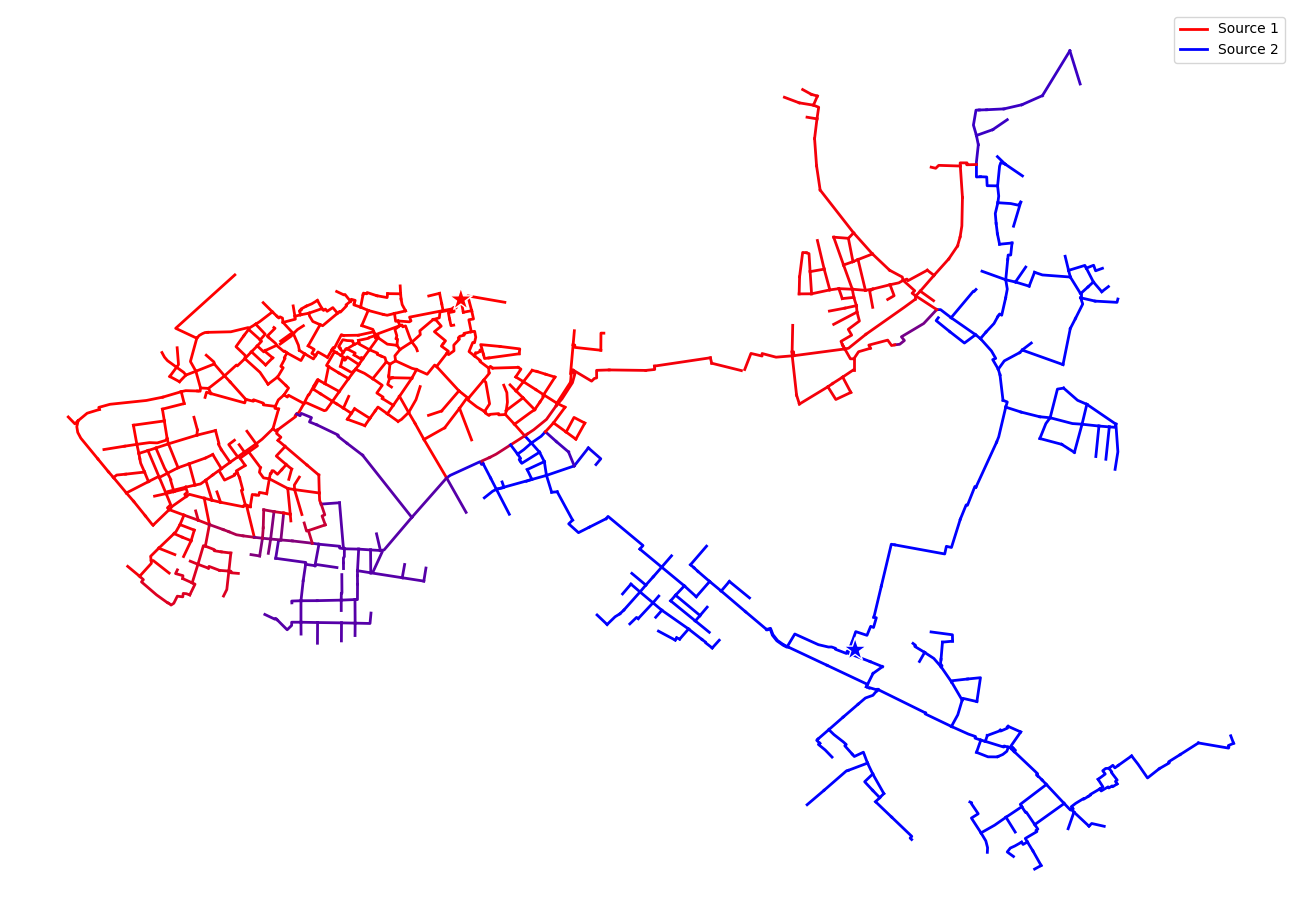

In [19]:
fig, ax = plt.subplots(figsize=Rm.DINA3q)
ncd.plot_src_spectrum(ax, dfROHR,'srcvector_plot', colors)

# Points
pts = np.array([src_A_coords, src_B_coords])
ax.scatter(pts[:, 0], pts[:, 1],
           s=300, marker='*',
           c=edge_colors,
           edgecolors='white', linewidths=1.0,
           zorder=10, label='Selected points')


plt.show()

xlim = ax.get_xlim()
ylim = ax.get_ylim()
canvas_center = ((xlim[0] + xlim[1]) / 2, (ylim[0] + ylim[1]) / 2)

fig.savefig('Example7_Output_1.pdf')

For each pipe a color (between A: red and B: blue) is mixed based on the srcvector present in its start and end node.

## Plotting with Pie Charts

### Preparing Data

In [20]:
dfROHR['srcvector_plot'] = dfROHR['srcvector_plot'].apply(lambda x: tuple(x) if isinstance(x, list) else x)

In [21]:
unique_values = dfROHR['srcvector_plot'].unique()

In [22]:
df = pd.DataFrame({
    'srcvector_plot': unique_values,
    'geometry': [dfROHR[dfROHR['srcvector_plot'] == value]['geometry'].iloc[0] for value in unique_values]
})

In [23]:
df[['left', 'right']] = pd.DataFrame(df['srcvector_plot'].tolist(), index=df.index)

df['left'] = df['left'].astype(int)
df['right'] = df['right'].astype(int)

In [24]:
df['pos'] = df['geometry'].apply(lambda geom: geom.interpolate(0.5) if isinstance(geom, LineString) else None)

In [25]:
def create_offset_point_away_from_midpoint(midpoint, canvas_center, scale=0.5):
    if midpoint is not None:
        # Calculate the direction vector from the canvas center to the midpoint
        direction_vector = Point(midpoint.x - canvas_center[0], midpoint.y - canvas_center[1])
        
        # Normalize the direction vector
        magnitude = (direction_vector.x**2 + direction_vector.y**2)**0.5
        normalized_vector = Point(direction_vector.x / magnitude, direction_vector.y / magnitude)
        
        # Create a point away from the midpoint in the direction away from the canvas center
        offset_point = Point(midpoint.x + normalized_vector.x * scale, midpoint.y + normalized_vector.y * scale)
        
        return offset_point
    return None

In [26]:
df['offset_point'] = df['pos'].apply(lambda pos: create_offset_point_away_from_midpoint(pos, canvas_center, scale=3000))

In [27]:
def create_circle_around_offset_point(offset_point, radius=1000):
    if offset_point is not None:
        return Point(offset_point.x, offset_point.y).buffer(radius)
    return None

In [28]:
df['circle'] = df['offset_point'].apply(lambda offset_point: create_circle_around_offset_point(offset_point, radius=1000))

In [29]:
#df.head()

In [30]:
df['helper_line'] = df.apply(lambda row: LineString([row['pos'], row['offset_point'].representative_point()]) if row['offset_point'] is not None else None, axis=1)

In [31]:
df = df.sort_values(by='left', ascending=True)

### Plot

In [32]:
colors2=['red','blue']

In [33]:
def plot_pie_charts_v2(ax, indexes, size=0.3, font_size=10, alpha=0.5):
    for index in indexes:
        if index < 0 or index >= len(df):
            print(f"Index {index} out of range")
            continue
        
        x = df['left'].iloc[index]
        y = df['right'].iloc[index]
        pos = df['pos'].iloc[index]

        x = int(x)
        y = int(y)
        circle = df['circle'].iloc[index]
        helper_line = df['helper_line'].iloc[index]
        
        if circle is not None:
            # Get the centroid of the circle to place the pie chart
            centroid = circle.centroid
            
            # Place the pie chart at the centroid of the circle
            inset_ax = ax.inset_axes([centroid.x, centroid.y, size, size], transform=ax.transData)
            pie_wedges, texts, autotexts = inset_ax.pie([x, y], labels=[' ', ' '], autopct='%1.1f%%', colors=colors2, textprops={'fontsize': font_size})
            
            # Set the alpha value for the pie chart wedges
            for wedge in pie_wedges:
                wedge.set_alpha(alpha)
            
            # Plot the helper line from the midpoint to the pie chart
            if helper_line is not None:
                ax.plot(*helper_line.xy, 'k--', transform=ax.transData)
    # Plot all offset points
    offset_points = df['offset_point'].dropna()
    ax.scatter([point.x for point in offset_points], [point.y for point in offset_points], color='red', label='Offset Points')

In [34]:
def interactive_plot_2(**kwargs):
    fig, ax = plt.subplots(figsize=Rm.DINA3q)  
    ncd.plot_src_spectrum(ax, dfROHR, 'srcvector_plot', colors)
    
    for i in range(len(df)): 
        if kwargs.get(f'Index_{i}', False):
            plot_pie_charts_v2(ax, [i], size=750)
    
    plt.show()

In [35]:
# Create checkboxes with proportions and index as descriptions
checkboxes_2 = {f'Index_{i}': widgets.Checkbox(value=False, description=f'{i}: {df["left"].iloc[i]}/{df["right"].iloc[i]}') for i in range(len(unique_values))}

In [36]:
widgets_interact_2 = widgets.interactive(interactive_plot_2, **checkboxes_2)

In [37]:
def update_plot_2(change):
    plt.clf()
    interactive_plot_2(**{key: checkboxes_2[key].value for key in checkboxes_2})

In [38]:
for key in checkboxes_2:
    checkboxes_2[key].observe(update_plot_2, names='value')

In [39]:
display(widgets_interact_2)

interactive(children=(Checkbox(value=False, description='0: 0/100'), Checkbox(value=False, description='1: 5/9…

The depiction of the interactive Widget plot does not work in the documentation, because a python kernel must run it. It is identical to the output plot apart from the possibilty to toggle a total of 20 pie charts individually. To interact with the plot, download and run the script.

# Example 7.2 Water age

## Read Model and Results

In [60]:
dbFilename="Example7_2"

In [61]:
dbFile = resources.files("PT3S").joinpath("Examples", f"{dbFilename}.db3")

In [62]:
m=dxAndMxHelperFcts.readDxAndMx(dbFile=dbFile
                                ,preventPklDump=True
                                ,maxRecords=-1
                                ,SirCalcExePath=r"C:\3S\SIR 3S\SirCalc-90-14-02-12_Potsdam.fix1_x64\SirCalc.exe"
                                )

INFO    ; Dx.__init__: dbFile (abspath): c:\users\aUserName\3s\pt3s\PT3S\Examples\Example7_2.db3 exists readable ...
INFO    ; Dx.__init__:  SYSTEMKONFIG ID 3 not defined. Value(ID=3) is supposed to define the Model which is used in QGIS. Now QGISmodelXk is undefined ...
INFO    ; PT3S.dxAndMxHelperFcts.readDxAndMx:  QGISmodelXk not defined. Now the MX of 1st Model in VIEW_MODELLE is used ...
INFO    ; PT3S.dxAndMxHelperFcts.readDxAndMx: 
+..\PT3S\Examples\Example7_2.db3 is newer than
+..\PT3S\Examples\WDExample7_2\B1\V0\BZ1\M-1-0-1.1.MX1:
+SIR 3S' dbFile is newer than SIR 3S' mx1File
+in this case the results are maybe dated or (worse) incompatible to the model
INFO    ; PT3S.dxAndMxHelperFcts.readDxAndMx: Model is being recalculated using C:\3S\SIR 3S\SirCalc-90-14-02-12_Potsdam.fix1_x64\SirCalc.exe
INFO    ; Mx.setResultsToMxsFile: Mxs: ..\PT3S\Examples\WDExample7_2\B1\V0\BZ1\M-1-0-1.1.MXS reading ...
INFO    ; dxWithMx.__init__: Example7_2: processing dx and mx ...


## SIR 3S results

### Preparing Data

In [64]:
dfKNOT=m.V3_KNOT

In [65]:
dfROHR=m.V3_ROHR

In [66]:
# Build lookup Series from dfKNOT
lookup_TTR = dfKNOT.set_index('pk')['TTR']
lookup_XKOR = dfKNOT.set_index('pk')['XKOR']
lookup_YKOR = dfKNOT.set_index('pk')['YKOR']

In [67]:
# Map fkKI and fkKK to TTR
dfROHR['TTR_KI'] = dfROHR['fkKI'].map(lookup_TTR)
dfROHR['TTR_KK'] = dfROHR['fkKK'].map(lookup_TTR)

In [68]:
# Map fkKI and fkKK to XKOR
dfROHR['XKOR_KI'] = dfROHR['fkKI'].map(lookup_XKOR)
dfROHR['XKOR_KK'] = dfROHR['fkKK'].map(lookup_XKOR)

In [69]:
# Map fkKI and fkKK to YKOR
dfROHR['YKOR_KI'] = dfROHR['fkKI'].map(lookup_YKOR)
dfROHR['YKOR_KK'] = dfROHR['fkKK'].map(lookup_YKOR)

In [70]:
dfROHR.head(3)

,pk,fkDE,rk,tk,fkKI,fkKK,fkDTRO_ROWD,fkLTGR,fkSTRASSE,L,...,VAVAbs,PHRAbs,JVAbs,MAV,TTR_KI,TTR_KK,XKOR_KI,XKOR_KK,YKOR_KI,YKOR_KK
0,4762947358005495341,5639119000213664939,4762947358005495341,4762947358005495341,5136506604482101815,5174640379525019821,4986198312707850071,5502864303090671858,-1,1000.0,...,0.349311,0.028210,0.028210,55.583332,0.000000,0.795216,149.999857,349.999964,500.000119,600.000024
1,5652222422293607654,5639119000213664939,5652222422293607654,5652222422293607654,5665004361761998834,5174640379525019821,4986198312707850071,5502864303090671858,-1,1000.0,...,0.349311,0.028210,0.028210,-55.583332,1.590431,0.795216,550.000072,349.999964,600.000024,600.000024
2,5479123649362439650,5639119000213664939,5479123649362439650,5479123649362439650,5665004361761998834,5185493728872360834,4986198312707850071,5502864303090671858,-1,1000.0,...,0.174656,0.007832,0.007832,27.791666,1.590431,3.180863,550.000072,749.999881,600.000024,649.999976


### Plotting

In [80]:
def plot_rohr_ttr_halves(
    dfROHR,
    x_ki='XKOR_KI', y_ki='YKOR_KI',
    x_kk='XKOR_KK', y_kk='YKOR_KK',
    ttr_ki='TTR_KI', ttr_kk='TTR_KK',
    cmap_name='viridis', lw=2.0, figsize=(10, 8),
    equal_aspect=True, title='Fluid age',
    cbar_label='TTR', use_percentiles=None  # e.g. (2,98) to clip color scale
):
    """Draw KI→midpoint colored by TTR_KI, midpoint→KK colored by TTR_KK."""

    # Helper: convert a column to float64 numpy array, coercing bad values to NaN
    def to_f64(col):
        return (pd.to_numeric(dfROHR[col], errors='coerce')
                  .astype('float64')
                  .to_numpy())

    # --- Coerce inputs to numeric arrays ---
    x0 = to_f64(x_ki); y0 = to_f64(y_ki)
    x1 = to_f64(x_kk); y1 = to_f64(y_kk)
    tki = to_f64(ttr_ki); tkk = to_f64(ttr_kk)

    # Midpoints
    xm = (x0 + x1) / 2.0
    ym = (y0 + y1) / 2.0

    # Valid masks
    valid_coords = np.isfinite(x0) & np.isfinite(y0) & np.isfinite(x1) & np.isfinite(y1)
    nonzero_len = np.hypot(x1 - x0, y1 - y0) > 0.0  # avoid zero-length segments
    base_mask = valid_coords & nonzero_len & np.isfinite(xm) & np.isfinite(ym)

    # Halves that can be colored
    mask1 = base_mask & np.isfinite(tki)
    mask2 = base_mask & np.isfinite(tkk)

    # If nothing to plot, bail politely
    if not (mask1.any() or mask2.any()):
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_title(f"{title} (no valid segments)")
        ax.set_aspect('equal', adjustable='box') if equal_aspect else None
        return fig, ax

    # Build segment arrays (n, 2, 2): [[x0,y0],[xm,ym]] and [[xm,ym],[x1,y1]]
    seg1 = np.stack([np.column_stack([x0[mask1], y0[mask1]]),
                     np.column_stack([xm[mask1], ym[mask1]])], axis=1) if mask1.any() else np.empty((0,2,2))
    seg2 = np.stack([np.column_stack([xm[mask2], ym[mask2]]),
                     np.column_stack([x1[mask2], y1[mask2]])], axis=1) if mask2.any() else np.empty((0,2,2))

    # Colormap + normalization
    cmap = get_cmap(cmap_name)
    all_vals = np.concatenate([tki[np.isfinite(tki)], tkk[np.isfinite(tkk)]])
    if all_vals.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        if use_percentiles and len(use_percentiles) == 2:
            lo, hi = np.nanpercentile(all_vals, use_percentiles)
            vmin, vmax = float(lo), float(hi) if hi > lo else (float(all_vals.min()), float(all_vals.max()))
        else:
            vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))
        if vmin == vmax:
            # Avoid a zero-width color scale
            vmin, vmax = vmin - 0.5, vmax + 0.5
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    if seg1.shape[0]:
        lc1 = LineCollection(seg1, cmap=cmap, norm=norm, linewidths=lw, zorder=2)
        lc1.set_array(tki[mask1])
        ax.add_collection(lc1)

    if seg2.shape[0]:
        lc2 = LineCollection(seg2, cmap=cmap, norm=norm, linewidths=lw, zorder=2)
        lc2.set_array(tkk[mask2])
        ax.add_collection(lc2)

    # Limits
    xs = np.concatenate([x0[valid_coords], x1[valid_coords]])
    ys = np.concatenate([y0[valid_coords], y1[valid_coords]])
    if xs.size and ys.size:
        ax.set_xlim(xs.min(), xs.max())
        ax.set_ylim(ys.min(), ys.max())

    if equal_aspect:
        ax.set_aspect('equal', adjustable='box')

    ax.set_title(title)

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    return fig, ax


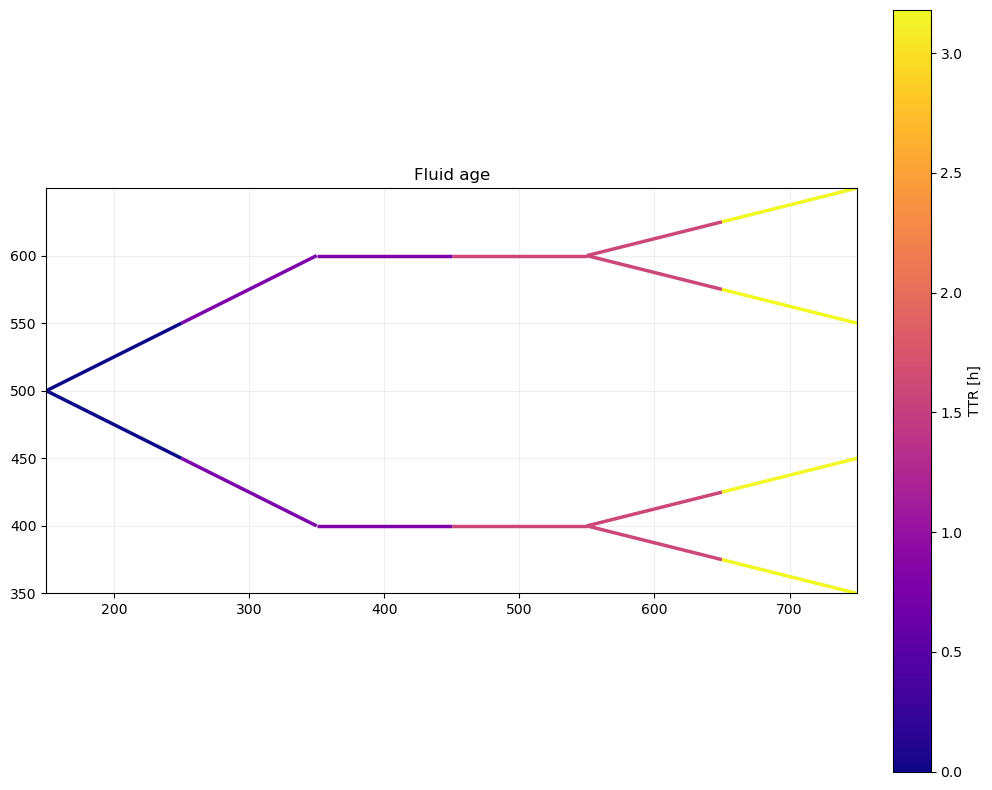

In [81]:
fig, ax = plot_rohr_ttr_halves(dfROHR,
                               x_ki='XKOR_KI', y_ki='YKOR_KI',
                               x_kk='XKOR_KK', y_kk='YKOR_KK',                                
                               ttr_ki='TTR_KI', ttr_kk='TTR_KK',
                            cmap_name='plasma', lw=2.5, cbar_label='TTR [h]')
#fig.savefig('ttr_halves.pdf', bbox_inches='tight')
plt.show()

## Comparision: Travel Time Matrix

In [73]:
TMAX_DETECT = 1.0e12

In [74]:
def setup_graph(df_data_results_edges):
    """Setup graph from edges data and results.

    Parameters
    ----------
    df_data_results_edges: pandas.DataFrame
        Edges data and results.

    Returns
    -------
    G : networkx.Graph
        Graph.
    """

    # Nodes: index mapping (here via tk of nodes, alternatively via names of nodes)
    list_nodes_tk = sorted(list(set(list(df_data_results_edges["tki"]) + list(df_data_results_edges["tkk"]))))
    map_nodes_tk_ind = {list_nodes_tk[ii]: ii for ii in range(len(list_nodes_tk))}

    # Adapt DataFrame
    df_data_results_edges["indi"] = df_data_results_edges["tki"].apply(lambda x: map_nodes_tk_ind[x])
    df_data_results_edges["indk"] = df_data_results_edges["tkk"].apply(lambda x: map_nodes_tk_ind[x])

    df_data_results_edges["indi_new"] = df_data_results_edges[["indi", "indk"]].min(axis=1)
    df_data_results_edges["indk_new"] = df_data_results_edges[["indi", "indk"]].max(axis=1)
    df_data_results_edges["dt_new"] = np.sign(df_data_results_edges["indk"] - df_data_results_edges["indi"])*df_data_results_edges["dt"]

    # Setup graph
    G = networkx.Graph()
    for _, row in df_data_results_edges.iterrows():
        G.add_edge(
            row['indi_new'],  # Start node
            row['indk_new'],  # End node
            # Additional edge attributes
            dt=row['dt_new']
        )

    # Out
    return G, map_nodes_tk_ind

In [75]:
def bfs_observedNodes(G, source, tmax):
    """Breadth-first-search starting at source.

    Parameters
    ----------
    G : networkx.Graph
        Graph.
    source : int
        Source node.
    tmax : float
        Maximum travel time.
    """

    visited = set([source])
    neighbors = G.neighbors
    queue = deque([(source, neighbors(source))])

    dt_travel_sum = {source: 0.0}

    while queue:
        parent, children = queue[0]

        try:
            child = next(children)

            edge = (min(parent, child), max(parent, child))
            sign_dt = np.sign(child - parent)

            dt_travel = sign_dt*G[edge[0]][edge[1]]['dt']
            dt_travel_sum[child] = dt_travel_sum[parent] + np.abs(dt_travel)

            if ((child not in visited) and (dt_travel_sum[child] < tmax) and dt_travel < 0.0):
                yield parent, child
                visited.add(child)
                queue.append((child, neighbors(child)))

        except StopIteration:
            queue.popleft()

In [76]:
def setup_travelTimeMatrix(df_data_results_edges):
    """Setup travel time matrix from edges data and results.

    Parameters
    ----------
    df_data_results_edges: pandas.DataFrame
        Edges data and results.

    Returns
    -------
    TMat : numpy.ndarray
        Travel time matrix.
    map_nodes_tk_ind : dict
        Mapping nodes tk to index.
    """

    # Setup graph
    G, map_nodes_tk_ind = setup_graph(df_data_results_edges)

    # Find sets of observed nodes by bfs search and setup matrix V
    obsNodes = {}
    obsNodesL = {}

    travelTimesAccObsNodesDict = {}

    for iSens in G.nodes:

        bfs_edges = list(bfs_observedNodes(G, iSens, TMAX_DETECT))

        nodesSet = set()
        endNodeLDict = {}

        for (lli, llk) in bfs_edges:
            nodesSet.add(lli)
            nodesSet.add(llk)
            edgex = (min(lli, llk), max(lli, llk))
            endNodeLDict[llk] = G[edgex[0]][edgex[1]]['dt']

        if (len(nodesSet) > 0):
            obsNodes[iSens] = nodesSet - {iSens}
            obsNodesL[iSens] = endNodeLDict

        # Calculate travel time matrix data
        edgesListUse = []
        for edgex in bfs_edges:
            (ix, kx) = edgex
            ix_new, kx_new = min(ix, kx), max(ix, kx)
            weight = abs(G[ix_new][kx_new]['dt'])
            edgesListUse.append((ix_new, kx_new, weight))

        Gtrav = networkx.Graph()
        if (len(edgesListUse) > 0):
            Gtrav.add_weighted_edges_from(edgesListUse)
            travelTimesAccObsNodesDict[iSens] = networkx.single_source_dijkstra_path_length(
                Gtrav, source=iSens, cutoff=None, weight='weight')

    # Setup travel time matrix
    rowsTTrav = []
    columnsTTrav = []
    dataTTrav = []

    for iSens in obsNodes.keys():
        # travel time from node to sensor
        ttravs = travelTimesAccObsNodesDict[iSens]
        for iObserved in ttravs:
            rowsTTrav.append(iSens)
            columnsTTrav.append(iObserved)
            dataTTrav.append(ttravs[iObserved])

    TMatSparse = csc_matrix((dataTTrav, (rowsTTrav, columnsTTrav)), shape=(len(G.nodes), len(G.nodes)))

    # Trafo to dense matrices
    TMat = 1.0*TMatSparse.toarray()

    # Out
    return TMat, map_nodes_tk_ind

In [77]:
TMat, map_nodes_tk_ind = setup_travelTimeMatrix(df_edges)

NameError: name 'df_edges' is not defined

In [ ]:
numpy.set_printoptions(linewidth=200)
TMat.round(1)